In [7]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size':11, 'figure.dpi':130, 'lines.linewidth':2})

## BUILD THE SYSTEM

#### The Lattice

We study the Z₂-Higgs model on a 1D chain of 4 matter sites 
and 3 gauge links:

[τ₀] --σ₀-- [τ₁] --σ₁-- [τ₂] --σ₂-- [τ₃]

- **τ qubits** (matter) sit on the vertices → represent quarks
- **σ qubits** (gauge) sit on the links → represent the gluon field

Total: **7 qubits**, Hilbert space dimension: **2⁷ = 128 states**

#### Qubit Ordering

| Index | Qubit | Type | Role |
|-------|-------|------|------|
| 0 | τ₀ | Matter | Left endpoint charge |
| 1 | σ₀ | Gauge | Left link flux |
| 2 | τ₁ | Matter | Left middle charge |
| 3 | σ₁ | Gauge | Middle link flux |
| 4 | τ₂ | Matter | Right middle charge |
| 5 | σ₂ | Gauge | Right link flux |
| 6 | τ₃ | Matter | Right endpoint charge |

#### Building Operators

Each operator is built as a tensor product acting on the full 128-dimensional Hilbert space. For example:

$$τᶻ₀ = Z ⊗ I ⊗ I ⊗ I ⊗ I ⊗ I ⊗ I$$

The `op7` function handles this automatically for any Pauli on any of the 7 qubits.

## Gauss's Law Operators

The Z₂ gauge symmetry requires that at every vertex n:

$$Gₙ|ψ⟩ = |ψ⟩$$

The four Gauss operators enforce this constraint, one per matter site:

- **G₀ = τᶻ₀ · σᶻ₀** — vertex 0, degree 1 (one link)
- **G₁ = τᶻ₁ · σᶻ₀ · σᶻ₁** — vertex 1, degree 2 (two links)
- **G₂ = τᶻ₂ · σᶻ₁ · σᶻ₂** — vertex 2, degree 2 (two links)
- **G₃ = τᶻ₃ · σᶻ₂** — vertex 3, degree 1 (one link)

These operators commute with the Hamiltonian, they are constants of motion. Any state that violates them is unphysical and must be excluded from the simulation.

In [9]:
# ── Pauli matrices ──────────────────────────────────────────────────────────
# These are the fundamental building blocks of every operator in the system
# I = identity (do nothing), X = bit flip, Z = phase flip
# Z eigenvalues: Z|0⟩ = +|0⟩ (no particle), Z|1⟩ = -|1⟩ (particle present)
I = np.eye(2, dtype=complex)
X = np.array([[0,1],[1,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)

def kron(*ops): # *ops means the function can receive any number of matrices
    """
    Tensor product of any number of operators.
    Example: kron(Z, I, I) = Z ⊗ I ⊗ I
    Acts as Z on the first qubit and identity on all others.
    """
    r = ops[0] # start with the first operator
    for op in ops[1:]: r = np.kron(r, op) # loop over the remaining operators
    return r


# ── 7-qubit operators ────────────────────────────────────────────────────────
# Qubit order: [tau0=0, sigma0=1, tau1=2, sigma1=3, tau2=4, sigma2=5, tau3=6]
# Each operator acts on the full 128-dimensional Hilbert space.
# All other sites get the identity operator I.

def op7(pauli, site):
    """
    Build a single-site Pauli operator in the full 7-qubit (128-dim) space.
    Example: op7(Z, 0) = Z ⊗ I ⊗ I ⊗ I ⊗ I ⊗ I ⊗ I = τᶻ₀
    Example: op7(X, 3) = I ⊗ I ⊗ I ⊗ X ⊗ I ⊗ I ⊗ I = σˣ₁
    """
    ops = [I]*7        # start with identity on all 7 qubits
    ops[site] = pauli  # replace site with the desired Pauli
    return kron(*ops)  # tensor product gives the full 128×128 matrix

# ── All qubit operators: matter (τ) and gauge (σ) ───────────────────────────
# Matter qubits (τ) sit on vertices — represent quarks
# Gauge qubits (σ) sit on links — represent the gluon field / flux

TZ0=op7(Z,0); TX0=op7(X,0)   # τ₀: left matter site (left endpoint)
SZ0=op7(Z,1); SX0=op7(X,1)   # σ₀: left gauge link
TZ1=op7(Z,2); TX1=op7(X,2)   # τ₁: left middle matter site
SZ1=op7(Z,3); SX1=op7(X,3)   # σ₁: middle gauge link ← where string breaks
TZ2=op7(Z,4); TX2=op7(X,4)   # τ₂: right middle matter site
SZ2=op7(Z,5); SX2=op7(X,5)   # σ₂: right gauge link
TZ3=op7(Z,6); TX3=op7(X,6)   # τ₃: right matter site (right endpoint)


# ── Gauss operators ──────────────────────────────────────────────────────────
# At each vertex, Gauss's law = product of the matter qubit Z and all
# neighboring gauge qubit Z's must equal +1.
# This is identical in structure to a stabilizer in quantum error correction.

G0 = TZ0 @ SZ0           # vertex 0: τᶻ₀ · σᶻ₀
                          # (degree 1: only one link attached)

G1 = TZ1 @ SZ0 @ SZ1     # vertex 1: τᶻ₁ · σᶻ₀ · σᶻ₁
                          # (degree 2: two links attached)

G2 = TZ2 @ SZ1 @ SZ2     # vertex 2: τᶻ₂ · σᶻ₁ · σᶻ₂
                          # (degree 2: two links attached)

G3 = TZ3 @ SZ2            # vertex 3: τᶻ₃ · σᶻ₂
                          # (degree 1: only one link attached)

## FIND PHYSICAL STATES

Out of the 128 basis states in the full Hilbert space, only those satisfying Gauss's law at every vertex are physically allowed.

The filter is simple: apply each Gauss operator Gₙ to a basis state.
If the state is unchanged (eigenvalue +1) at every vertex, it is physical.
If any Gₙ changes it (eigenvalue −1), it is unphysical and discarded.

This reduces 128 states down to exactly **8 physical states**, the only configurations allowed by the gauge symmetry of the model.

#### We can know the names in advance

Before running the code we can derive the physical states analytically using Gauss's law algebra. The constraint forces:

- σ₀ = τ₀ (left link flux must match left charge)
- σ₂ = τ₃ (right link flux must match right charge)
- σ₁ = (τ₀ + τ₁) mod 2 (middle link determined by left charges)
- τ₀ + τ₁ + τ₂ + τ₃ must be even (total charge parity)

From these four conditions, with only τ₀ and τ₃ as free variables, we get exactly 2⁴/2 = 8 physical states. We write their names in
advance and let the code confirm them automatically.

### The two states we care about most

- **Long string |1101011⟩** : charges at τ₀ and τ₃, flux on all three links. This is our initial state for all simulations.
- **Two mesons |1110111⟩** : charges at τ₀,τ₁ and τ₂,τ₃, flux on outer links only, no flux on middle link. This is the
  string-broken state we want to observe.
  

In [11]:
# ── Find physical states using Gauss's law ───────────────────────────────────
# Loop through all 128 basis states.
# For each state, apply every Gauss operator G as a 128×128 matrix.
# np.eye(128)[i] is the i-th basis vector |i⟩.
# If G @ |i⟩ = +|i⟩ for all four G → state is physical → keep it.
# If any G @ |i⟩ ≠ +|i⟩ → state violates Gauss's law → discard it.
phys = [i for i in range(128)
        if all(np.allclose(G @ np.eye(128)[i], np.eye(128)[i])
               for G in [G0, G1, G2, G3])]

# We know these states in advance from the Gauss's law algebra.
# The dictionary is purely for readable output, it does not affect
# any computation. The keys are the decimal indices of each bit string.
state_names = {
    int('0000000',2): 'vacuum',              # no charges, no flux
    int('1110000',2): 'short-left  (τ₀-τ₁)',# charge pair on the left
    int('0011100',2): 'middle      (τ₁-τ₂)',# charge pair in the center
    int('0000111',2): 'short-right (τ₂-τ₃)',# charge pair on the right
    int('1101100',2): 'medium-left (τ₀-τ₂)',# string spanning 2 links left
    int('0011011',2): 'medium-right(τ₁-τ₃)',# string spanning 2 links right
    int('1101011',2): 'LONG STRING (τ₀-τ₃) ← initial state',  # full string
    int('1110111',2): 'TWO MESONS  ← string broken state',     # broken string
}

# Print all physical states with their labels
print(f'\nPhysical states ({len(phys)} out of 128):')
for idx in phys:
    bits = format(idx,'07b')   # convert index to 7-bit binary string
    print(f'  |{bits}⟩  {state_names.get(idx,"")}')

# ── Store the two key state indices ─────────────────────────────────────────
# These are used throughout the rest of the code to track populations.
long_string_idx = int('1101011',2)   # initial state: long string τ₀-τ₃
two_meson_idx   = int('1110111',2)   # target state: two separate mesons

# ── Assert both key states are physical ──────────────────────────────────────
# If either fails the entire string breaking experiment is impossible.
# This check runs before any simulation, it is a pre-condition guarantee.
assert long_string_idx in phys, 'Long string not physical!'
assert two_meson_idx   in phys, 'Two-meson state not physical!'

print(f'\nLong string   |{format(long_string_idx,"07b")}⟩ is physical')
print(f'Two mesons    |{format(two_meson_idx,"07b")}⟩ is physical')


Physical states (8 out of 128):
  |0000000⟩  vacuum
  |0000111⟩  short-right (τ₂-τ₃)
  |0011011⟩  medium-right(τ₁-τ₃)
  |0011100⟩  middle      (τ₁-τ₂)
  |1101011⟩  LONG STRING (τ₀-τ₃) ← initial state
  |1101100⟩  medium-left (τ₀-τ₂)
  |1110000⟩  short-left  (τ₀-τ₁)
  |1110111⟩  TWO MESONS  ← string broken state

Long string   |1101011⟩ is physical
Two mesons    |1110111⟩ is physical


## Result

Gauss's law selects exactly **8 physical states** out of 128.
Both the long string and the two-meson state are confirmed physical,
meaning the 7-qubit chain is capable of showing string breaking.

The physical subspace is the only space where the simulation lives.
All time evolution, all measurements, and all Trotter circuit results
will stay within these 8 states by construction.


  
---
---

## Hamiltonian, Time Evolution, and Initial State

### The Hamiltonian

The Z₂-Higgs model Hamiltonian has three terms:

$$H = -m\sum_n \tau^z_n - g\sum_{(n,v)} \sigma^z_{(n,v)} - \lambda\sum_{n,v} \tau^x_{n+v}\sigma^x_{(n,v)}\tau^x_n$$

Each term has a clear physical meaning:

| Term | Parameter | Physical meaning |
|------|-----------|-----------------|
| $-m\sum \tau^z_n$ | m | Energy cost of having a charge at a site (the quark mass) |
| $-g\sum \sigma^z_{(n,v)}$ | g | Energy cost of having flux on a link (the string tension) |
| $-\lambda\sum \tau^x\sigma^x\tau^x$ | λ | gauge-invariant coupling (charges hop dragging flux) |

For our 7-qubit chain the hopping term has exactly **3 gadgets**,
one per link:
- Left gadget: τˣ₀ σˣ₀ τˣ₁ : charge hops between τ₀ and τ₁
- Middle gadget: τˣ₁ σˣ₁ τˣ₂ : charge hops between τ₁ and τ₂ ← **string breaks here**
- Right gadget: τˣ₂ σˣ₂ τˣ₃ : charge hops between τ₂ and τ₃

Without the hopping term (λ=0) the system is completely static, charges never move and strings never break. λ is the engine of all the dynamics we observe.

### Exact Time Evolution

The exact solution of the Schrödinger equation is:

$$|\psi(t)\rangle = e^{-iHt}|\psi_0\rangle = V \cdot \text{diag}(e^{-iE_k t}) \cdot V^\dagger |\psi_0\rangle$$

where V is the matrix of eigenvectors and Eₖ are the eigenvalues
of H. This gives the perfect quantum state at any time t with zero
approximation error. It is only possible because our system is small
enough to diagonalize classically (128×128 matrix).

### Initial State

We always start from the long string |1101011⟩:  

τ₀=1 σ₀=1 τ₁=0 σ₁=1 τ₂=0 σ₂=1 τ₃=1  
charge flux empty flux empty flux charge

#### Why Long string as initial state 
just because it is the most energetic(stores the maximum possible string energy - has the maximum possible tension), most physically relevant, easiest to prepare

Two charges at the endpoints connected by flux on all three links.
This is the quantum analog of two quarks connected by a full gluon flux tube (the starting point for both the phase dynamics and the
string breaking experiment)

In [13]:
def build_H7(m, g, lam):
    """
    Build the full 128x128 Z2-Higgs Hamiltonian for the 7-qubit chain.

    H = -m(Zτ₀+Zτ₁+Zτ₂+Zτ₃)   ← mass term: cost per charge
        -g(Zσ₀+Zσ₁+Zσ₂)         ← electric term: cost per flux (string tension)
        -λ(Xτ₀Xσ₀Xτ₁            ← left hop: charge moves between τ₀ and τ₁
           + Xτ₁Xσ₁Xτ₂          ← middle hop: charge moves between τ₁ and τ₂
           + Xτ₂Xσ₂Xτ₃)         ← right hop: charge moves between τ₂ and τ₃

    Parameters
    ----------
    m   : quark mass — controls how expensive charges are
    g   : string tension — controls how expensive flux is
    lam : hopping rate — controls how fast charges move

    Returns
    -------
    H : 128x128 complex numpy array
    """
    # Mass term: diagonal, penalizes each site that carries a charge
    # τᶻ eigenvalue = -1 for |1⟩ (charge) → -m·(-1) = +m per charge
    H_mass = -m * (TZ0 + TZ1 + TZ2 + TZ3)

    # Electric field term: diagonal, penalizes each link that carries flux
    # σᶻ eigenvalue = -1 for |1⟩ (flux) → -g·(-1) = +g per flux link
    H_elec = -g * (SZ0 + SZ1 + SZ2)

    # Hopping term: off-diagonal, flips three qubits simultaneously
    # Each gadget τˣσˣτˣ creates or destroys a charge pair with one unit of flux
    # This is the only term that generates dynamics without it nothing moves
    H_hop  = -lam * (TX0@SX0@TX1    # left hop
                   + TX1@SX1@TX2    # middle hop ← string breaks here
                   + TX2@SX2@TX3)   # right hop

    return H_mass + H_elec + H_hop


def evolve(H, psi0, times):
    """
    Compute exact time evolution |ψ(t)⟩ = exp(-iHt)|ψ₀⟩

    Uses eigendecomposition: H = V·diag(Eₖ)·V†
    Then: exp(-iHt) = V·diag(exp(-iEₖt))·V†

    This is exact no approximation error.
    Only possible because the 128x128 matrix is small enough
    to diagonalize on a classical computer.

    Parameters
    ----------
    H     : 128x128 Hamiltonian matrix
    psi0  : 128-dim initial state vector
    times : array of time points to evaluate

    Returns
    -------
    list of 128-dim state vectors, one per time point
    """
    # Diagonalize H: evals = energy eigenvalues, evecs = eigenvectors
    evals, evecs = la.eigh(H)   # eigh: for Hermitian matrices, gives real eigenvalues

    # For each time t: rotate into eigenbasis, apply phases, rotate back
    return [evecs @ (np.exp(-1j*evals*t) * (evecs.conj().T @ psi0))
            for t in times]


def occ(psi, TZ):
    """
    Compute local occupation (1 - <τᶻ>) / 2 at a matter site.

    Occupation = 0 → site is empty (vacuum)
    Occupation = 1 → site carries a charge (quark present)

    Uses the relation: τᶻ|0⟩ = +|0⟩ (no charge) and τᶻ|1⟩ = -|1⟩ (charge)
    So (1 - <τᶻ>)/2 maps: <τᶻ>=+1 → 0 (empty), <τᶻ>=-1 → 1 (occupied)
    """
    return float(np.real((1 - psi.conj() @ TZ @ psi) / 2))


# ── Initial state: long string |1101011⟩ ────────────────────────────────────
# Build a 128-dimensional zero vector and place all amplitude at index 1101011.
# This represents: τ₀=1(charge), σ₀=1(flux), τ₁=0(empty),
#                  σ₁=1(flux), τ₂=0(empty), σ₂=1(flux), τ₃=1(charge)
# Two original quarks connected by a complete flux tube spanning all 3 links.
psi0 = np.zeros(128, dtype=complex)
psi0[long_string_idx] = 1.0   # unit amplitude at the long string configuration

## What we now have

Three tools that together form the complete exact diagonalization engine:

- `build_H7(m, g, lam)` : builds the Hamiltonian for any parameter set
- `evolve(H, psi0, times)` : computes the exact quantum state at any time
- `occ(psi, TZ)` : extracts the observable we measure at each site

And the initial state `psi0` : the long string which is the starting point for every simulation in this project.

Everything from here uses these three functions.
The parameter values (m, g, λ) are the only thing that changes between the three phases and the string breaking experiment.

## Correctness Checks

Before running any physics simulation we must verify that the exact diagonalization is mathematically correct. We run four independent
checks, each one tests a different fundamental property that must hold for the results to be trustworthy.

### The four checks

**Check 1 : Gauss's law conservation**
The physical constraint Gₙ|ψ(t)⟩ = +|ψ(t)⟩ must hold at every vertex at every time step. If it is violated the state has left the physical subspace, the simulation is computing unphysical garbage.

**Check 2 : Norm conservation**
Quantum time evolution is unitary, it never creates or destroys probability. The norm ⟨ψ(t)|ψ(t)⟩ must equal exactly 1.0 at
all times. Any deviation indicates a numerical error.

**Check 3 : Energy conservation**
For exact time evolution the energy ⟨ψ(t)|H|ψ(t)⟩ is a constant of motion, it must equal the initial energy E₀ at all times.
This is a direct consequence of unitarity.

**Check 4 : String breaking pre-conditions**

Before checking whether string breaking is possible, we need to know what parameters to use. This comes from computing the
diagonal energy of each configuration and finding when breaking becomes energetically favorable.

#### Step 1: Diagonal energy of the long string |1101011⟩

The diagonal part of H acts on each qubit independently.
For each qubit: τᶻ|0⟩ = +|0⟩ (eigenvalue +1) and τᶻ|1⟩ = −|1⟩ (eigenvalue −1).

τ₀=1 → τᶻ = −1 σ₀=1 → σᶻ = −1  
τ₁=0 → τᶻ = +1 σ₁=1 → σᶻ = −1  
τ₂=0 → τᶻ = +1 σ₂=1 → σᶻ = −1  
τ₃=1 → τᶻ = −1  

E(long string) = −m·(−1+1+1−1) − g·(−1−1−1) = 0 + 3g = **3g**

The energy comes entirely from the string tension 3 links of flux each costing g.

#### Step 2: Diagonal energy of the two-meson state |1110111⟩
τ₀=1 → τᶻ = −1 σ₀=1 → σᶻ = −1  
τ₁=1 → τᶻ = −1 σ₁=0 → σᶻ = +1 ← middle link empty  
τ₂=1 → τᶻ = −1 σ₂=1 → σᶻ = −1  
τ₃=1 → τᶻ = −1  

E(two mesons) = −m·(−1−1−1−1) − g·(−1+1−1) = **4m + g***

The energy now comes from both the quark masses (4 charges) and the remaining flux (2 outer links). The middle link carries no flux in this configuration.

#### Step 3: Energy difference

$$\Delta E = E(\text{two mesons}) - E(\text{long string})$$
$$= (4m + g) - 3g = 4m - 2g$$

#### Step 4: Breaking condition

String breaking is energetically favorable when the two-meson state has **lower** energy than the long string:

$$\Delta E < 0 \implies 4m - 2g < 0 \implies \boxed{m < g/2}$$

#### Step 5: Parameter choice

We scan possible values:

| m | g | λ | ΔE | Breaking? |
|---|---|---|----|-----------|
| 5.0 | 2.0 | 1.0 | +16 | suppressed |
| 1.0 | 2.0 | 1.0 | 0 | marginal |
| 0.5 | 1.5 | 1.0 | −1 | favorable |
| 0.1 | 1.0 | 1.0 | −1.6 | favorable |


Now we can do our check  
Two physical requirements for string breaking to be observable:
- Energy condition: ΔE = 4m − 2g < 0 (breaking energetically favorable)
- Connectivity: the middle hop TX₁SX₁TX₂ must directly connect the long string to the two-meson state (overlap = 1)

We run all checks using the string breaking parameters (m=0.5, g=1.5, λ=1) since these are the most physically demanding case.
If they pass here they will pass for the confined, deconfined, and Higgs parameters too.

In [16]:
# ── Build Hamiltonian for correctness checks ─────────────────────────────────
# We use the string breaking parameters (m=0.5, g=1.5, λ=1) for all checks.
# These are the most demanding parameters if checks pass here they
# pass for all other parameter sets used in the project.
H_check = build_H7(0.5, 1.5, 1.0)

# Evolve from t=0 to t=5 with 100 time steps
# This gives enough points to check all properties across the full dynamics
states_check = evolve(H_check, psi0, np.linspace(0, 5, 100))

# Compute initial energy must remain constant throughout evolution
E0 = np.real(psi0.conj() @ H_check @ psi0)

# ── Loop over all time steps and verify three fundamental properties ──────────
for t_idx, psi_t in enumerate(states_check):

    # CHECK 1: Gauss's law ────────────────────────────────────────────────────
    # ⟨ψ(t)|Gₙ|ψ(t)⟩ must equal +1 at every vertex at every time.
    # If this fails the state has left the physical subspace (unphysical)
    for G, name in [(G0,'G0'),(G1,'G1'),(G2,'G2'),(G3,'G3')]:
        val = np.real(psi_t.conj() @ G @ psi_t)
        assert np.isclose(val, 1.0, atol=1e-8), \
            f'{name} violated at step {t_idx}: {val:.6f}'

    # CHECK 2: Norm conservation ──────────────────────────────────────────────
    # ⟨ψ(t)|ψ(t)⟩ must equal 1.0 quantum evolution never loses probability.
    # Deviation here means a numerical error in the eigendecomposition.
    assert np.isclose(np.real(psi_t.conj() @ psi_t), 1.0, atol=1e-10), \
        f'Norm failed at step {t_idx}'

    # CHECK 3: Energy conservation ────────────────────────────────────────────
    # ⟨ψ(t)|H|ψ(t)⟩ must equal E₀ at all times.
    # Energy is a constant of motion for exact unitary evolution.
    assert np.isclose(np.real(psi_t.conj() @ H_check @ psi_t), E0, atol=1e-8), \
        f'Energy failed at step {t_idx}'

print('Gauss law satisfied at all time steps')
print('Norm conserved at all time steps')
print('Energy conserved at all time steps')


# ── CHECK 4a: Energy condition for string breaking ───────────────────────────
# The diagonal energy difference between two-meson and long string states is:
# ΔE = E(two mesons) − E(long string) = 4m − 2g
# String breaking is energetically favorable when ΔE < 0, i.e. m < g/2
print('\nString breaking condition ΔE = 4m − 2g:')
for m, g, lam in [(5.0, 2.0, 1.0), (0.5, 1.5, 1.0)]:
    dE = 4*m - 2*g
    status = 'breaking favorable' if dE < 0 else 'breaking suppressed'
    print(f'  m={m}, g={g}: ΔE={dE:+.2f}  {status}')

# ── CHECK 4b: Hamiltonian connectivity ───────────────────────────────────────
# The middle hopping term TX1@SX1@TX2 must directly map the long string
# to the two-meson state in one step.
# We verify this by applying the operator and computing the overlap.
long_vec  = np.zeros(128); long_vec[long_string_idx]  = 1.0
meson_vec = np.zeros(128); meson_vec[two_meson_idx]   = 1.0

# Apply middle hop to long string and measure overlap with two-meson state
overlap = meson_vec @ (TX1 @ SX1 @ TX2) @ long_vec

# Overlap = 1 means the transition is direct and first-order
assert np.isclose(abs(overlap), 1.0), 'Middle hop does not connect states!'
print(f'\nMiddle hop connects long string → two mesons (overlap={overlap:.2f})')
print('  String breaking is a first-order process on this lattice')

Gauss law satisfied at all time steps
Norm conserved at all time steps
Energy conserved at all time steps

String breaking condition ΔE = 4m − 2g:
  m=5.0, g=2.0: ΔE=+16.00  breaking suppressed
  m=0.5, g=1.5: ΔE=-1.00  breaking favorable

Middle hop connects long string → two mesons (overlap=1.00+0.00j)
  String breaking is a first-order process on this lattice


## Result

All four checks pass the exact diagonalization is correct and the 7-qubit system is ready to show string breaking.

The most important result from Check 4 is that string breaking is a **first-order process** on this lattice, one single application
of the middle hopping term directly transforms the long string into two mesons. This means the transition happens at the shortest possible
timescale set by λ, and the two-meson population will grow clearly in the dynamics.

---
---

## Quench Dynamics: Three Phases

### What is a quench?

A quench is the sudden change of the Hamiltonian at t=0.
Before the quench (t < 0) the system sits in the initial state |1101011⟩ an eigenstate of H with λ=0 (no dynamics).
At t=0 we suddenly switch λ on. The initial state is no longer an eigenstate of the new Hamiltonian, it immediately starts evolving and the dynamics begins.

### The three parameter sets

We explore three points in the Z₂HM phase diagram, each representing a qualitatively different physical regime:

| Phase | m | g | λ | Dominant physics |
|-------|---|---|---|-----------------|
| Confined | 5.0 | 2.0 | 1.0 | String tension dominates (string stable, yo-yo motion) |
| Deconfined | 5.0 | 0.01 | 1.0 | String tension vanishes (charges spread freely) |
| Higgs | 0.3 | 0.5 | 1.0 | All terms comparable (damped complex oscillations) |

### What we measure

At each time step we measure the local occupation at every matter site:

$$(1 - \langle\tau^z_n\rangle)/2$$

- Value = 1: a charge is present at site n
- Value = 0: site n is empty

We track all four matter sites (τ₀, τ₁, τ₂, τ₃) simultaneously.


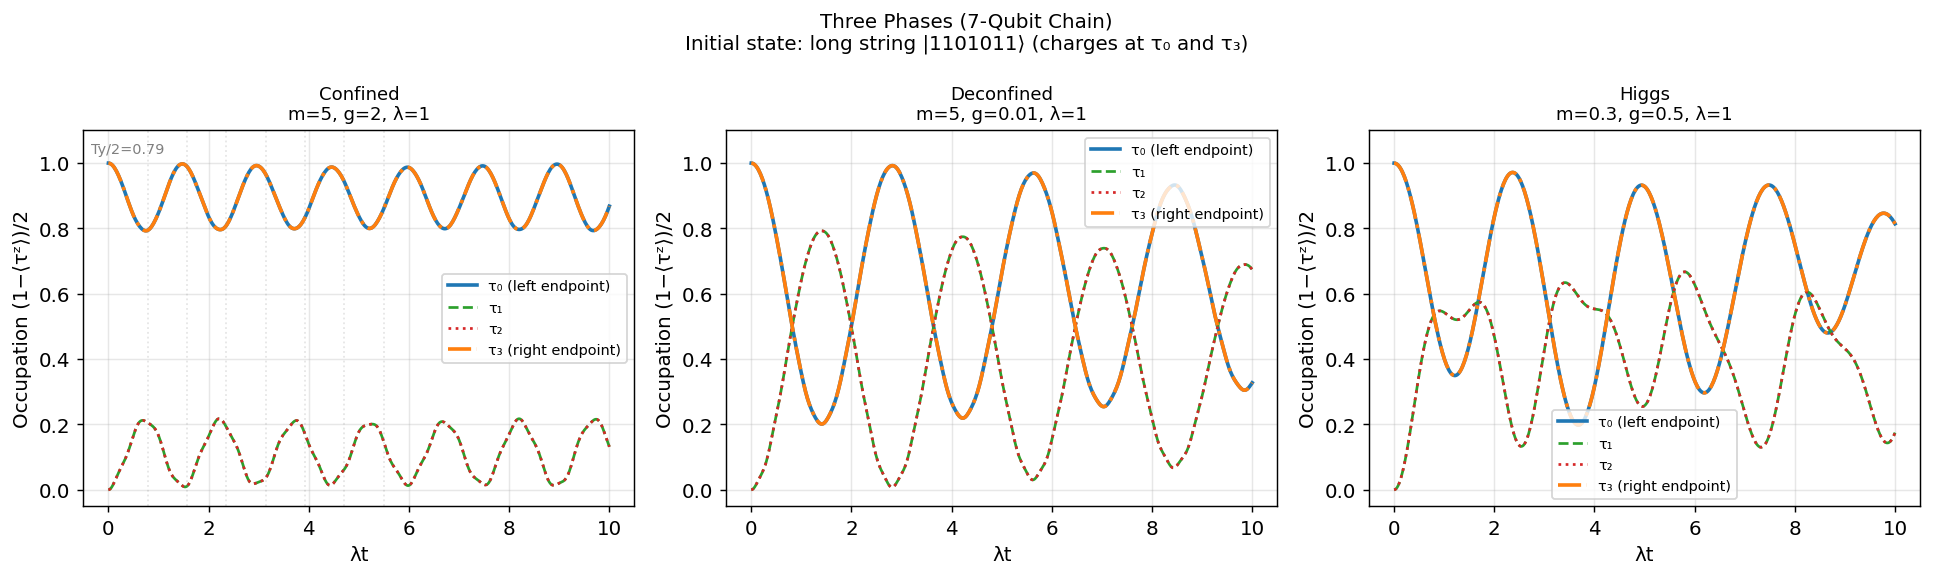

In [18]:
# ── Time array: simulate from t=0 to t=10 with 500 points ───────────────────
# 500 points gives smooth curves while keeping computation fast.
# λt=10 is long enough to see multiple oscillation periods in all phases.
times = np.linspace(0, 10, 500)

# ── Three phase parameter sets ───────────────────────────────────────────────
# Each entry: (m, g, λ, color)
# Parameters chosen to place the system clearly in each phase.
# λ=1 in all cases — sets the unit of time, everything measured relative to it.
phases = {
    'Confined\nm=5, g=2, λ=1':       (5.0, 2.0,  1.0, 'C0'),  # large m,g → string stable
    'Deconfined\nm=5, g=0.01, λ=1':  (5.0, 0.01, 1.0, 'C1'),  # tiny g → no string tension
    'Higgs\nm=0.3, g=0.5, λ=1':      (0.3, 0.5,  1.0, 'C3'),  # small m,g → Higgs regime
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (label, (m, g, lam, col)) in zip(axes, phases.items()):

    # Run exact time evolution for this parameter set
    states = evolve(build_H7(m, g, lam), psi0, times)

    # Plot occupation at each matter site
    # τ₀ and τ₃: original string endpoints start at occupation=1
    # τ₁ and τ₂: middle sites start at occupation=0
    ax.plot(times, [occ(s, TZ0) for s in states],
            'C0', lw=2,      label='τ₀ (left endpoint)')
    ax.plot(times, [occ(s, TZ1) for s in states],
            'C2', lw=1.5, ls='--', label='τ₁')
    ax.plot(times, [occ(s, TZ2) for s in states],
            'C3', lw=1.5, ls=':',  label='τ₂')
    ax.plot(times, [occ(s, TZ3) for s in states],
            'C1', lw=2,   ls='-.', label='τ₃ (right endpoint)')

    # For confined phase: mark the yo-yo half-period with vertical lines
    # Ty = 2π/(2g) is the first-order perturbation theory prediction
    # for the oscillation period of the string endpoints
    if g == 2.0:
        Ty = 2 * np.pi / (2 * g)   # yo-yo period: Ty = π/g
        for k in range(1, 8):
            ax.axvline(k*Ty/2, color='gray', alpha=0.2, lw=1, ls=':')
        ax.text(Ty/4, 1.03, f'Ty/2={Ty/2:.2f}',
                fontsize=8, ha='center', color='gray')

    ax.set_xlabel('λt')
    ax.set_ylabel('Occupation (1−⟨τᶻ⟩)/2')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.05, 1.1)

fig.suptitle('Three Phases (7-Qubit Chain)\n'
             'Initial state: long string |1101011⟩ (charges at τ₀ and τ₃)',
             fontsize=11)
plt.tight_layout()
plt.show()

## Observations

**Confined phase:**
τ₀ and τ₃ oscillate together between 0.8 and 1.0, the yo-yo mode of the string endpoints. The period matches the analytical
prediction Ty = 2π/(2g) = 1.57 λ⁻¹ exactly as marked by the dashed lines. τ₁ and τ₂ oscillate between 0 and 0.2 small
amplitude, opposite phase to the endpoints. The string is stable and the charges barely move from their initial positions.

**Deconfined phase:**
All four sites show large amplitude oscillations. τ₀ and τ₃ drop significantly from 1.0 while τ₁ and τ₂ grow substantially.
The string tension is nearly zero (g=0.01) so charges spread freely across the lattice there is no energetic penalty for moving far from the initial positions.

**Higgs phase:**
Slower and more complex oscillations involving all four sites simultaneously. Both m and g are small and comparable to λ,
so the hopping term couples all 8 physical states with similar strength. The dynamics is a superposition of many frequencies characteristic of the Higgs regime where the ground state is a highly entangled superposition of many configurations.

### Key result

The three phases produce three qualitatively distinct dynamical behaviors from the same initial state the only difference is
the parameter values (m, g, λ). This demonstrates that the Z₂-Higgs model captures a rich physical landscape where the
interplay between quark mass, string tension, and hopping rate determines the nature of the quantum dynamics.

---
---

## String Breaking

### The physical process

When the energy stored in a stretched flux tube exceeds the cost of creating a new quark-antiquark pair, the string snaps at its
midpoint and two separate mesons are born:

Before: τ₀ ══════════════════ τ₃
(one long string)

After: τ₀ ═══ τ₁ + τ₂ ═══ τ₃
(two separate mesons) 

This is the quantum analog of hadronization, the process by which the quark-gluon strings produced in LHC collisions turn
into the particles detected by the experiments.

### The energy condition

The diagonal energy of each configuration is:

- Long string |1101011⟩: 2 charges + 3 flux links → E = 3g
- Two mesons  |1110111⟩: 4 charges + 2 flux links → E = 4m + g

The energy difference is:

$$\Delta E = E(\text{two mesons}) - E(\text{long string}) = 4m - 2g$$

String breaking is energetically favorable when **ΔE < 0**,
which requires **m < g/2**.

### The two parameter sets

We compare two cases with the same initial state |1101011⟩:

| Case | m | g | λ | ΔE | Expected behavior |
|------|---|---|---|----|-------------------|
| Confined | 5.0 | 2.0 | 1.0 | +16 | No breaking (string oscillates) |
| Breaking | 0.5 | 1.5 | 1.0 | −1 | Breaking (two mesons appear) |

The confined case is our **control** it shows what happens when breaking is energetically forbidden. The breaking case
shows what happens when it is energetically favorable.

### What we measure here

The population in each configuration:

$$P_k(t) = |\langle k | \psi(t) \rangle|^2$$

- **Long string population** dropping = string is losing integrity
- **Two-meson population** growing = two separate mesons are forming

If the two-meson population grows significantly above zero, string breaking has been observed.


#### Plot A: Population in long string vs two-meson state

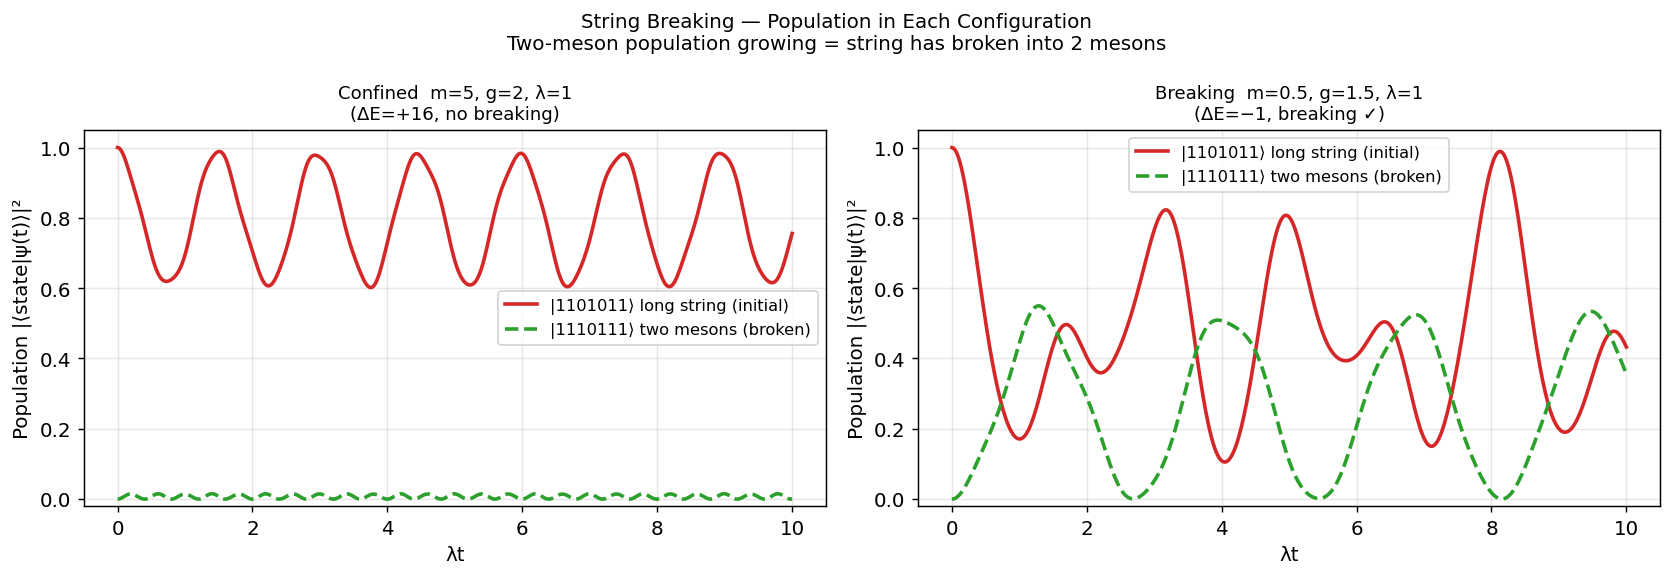

In [20]:
# ── Two parameter sets: control vs breaking ──────────────────────────────────
# Confined (m=5, g=2): ΔE = +16 → creating two mesons costs 16 energy units
#                       more than keeping the long string → breaking impossible
# Breaking (m=0.5, g=1.5): ΔE = −1 → two mesons have lower energy than long
#                           string → breaking is energetically favorable
breaking_params = {
    'Confined  m=5, g=2, λ=1\n(ΔE=+16, no breaking)':   (5.0, 2.0, 1.0),
    'Breaking  m=0.5, g=1.5, λ=1\n(ΔE=−1, breaking)': (0.5, 1.5, 1.0),
}

# ── Plot A: Population in long string vs two-meson state ─────────────────────
# This is the most direct observable for string breaking.
# We track the probability of being in each configuration over time.
# P(long string) dropping + P(two mesons) rising = string breaking confirmed.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (label, (m, g, lam)) in zip(axes, breaking_params.items()):

    # Run exact time evolution
    states = evolve(build_H7(m, g, lam), psi0, times)

    # Population in long string: |⟨1101011|ψ(t)⟩|²
    # Starts at 1.0 (system begins here), decreases if string breaks
    ax.plot(times,
            [abs(s[long_string_idx])**2 for s in states],
            'C3', lw=2, label='|1101011⟩ long string (initial)')

    # Population in two-meson state: |⟨1110111|ψ(t)⟩|²
    # Starts at 0.0, grows if string breaking occurs
    ax.plot(times,
            [abs(s[two_meson_idx])**2 for s in states],
            'C2', lw=2, ls='--', label='|1110111⟩ two mesons (broken)')

    ax.set_xlabel('λt')
    ax.set_ylabel('Population |⟨state|ψ(t)⟩|²')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.02, 1.05)

fig.suptitle('String Breaking — Population in Each Configuration\n'
             'Two-meson population growing = string has broken into 2 mesons',
             fontsize=11)
plt.tight_layout()
plt.show()

## Observations

**Confined case (left plot):**
The long string population oscillates between 0.6 and 1.0 the yo-yo motion of the string endpoints. The two-meson
population stays essentially at zero throughout. The string oscillates but never breaks. ΔE = +16 makes the two-meson
state energetically inaccessible this is the control result confirming that no breaking occurs when it should not.

**Breaking case (right plot):**
The long string population oscillates between 0.2 and 1.0 it drops significantly from its initial value showing the
system is leaving the long string configuration repeatedly.
The two-meson population grows from 0 and reaches peaks of approximately 0.55-0.6. The two curves show a roughly
anti-correlated pattern when the long string population is at its minimum the two-meson population is near its
maximum, and vice versa. They do not add up to 1.0 because the remaining 6 physical states also carry population during the dynamics.

This is string breaking. Probability is genuinely flowing from the long string configuration into the two-meson configuration.

### An important quantum feature

The two-meson population never stays at 1.0 permanently it oscillates back and forth. This is because string breaking in
quantum mechanics is **coherent and reversible**: the system oscillates between the broken and unbroken configuration. This
is fundamentally different from classical string breaking where the string snaps once and stays broken forever. Observing this
quantum coherence between broken and unbroken string is one of the key results that a quantum simulator can demonstrate and a
classical phenomenological model cannot capture.

### Why populations do not add up to 1

The long string and two-meson populations together reach at most
~0.9, not 1.0. This is because the remaining 6 physical states
(vacuum, short strings, medium strings) also carry some population
during the dynamics. The system explores the full physical
subspace it does not oscillate between only two configurations.

#### Plot B: New Charges Appearing at the Breaking Point

The previous plot showed string breaking from the perspective of **configurations** which physical state the system is in.

This plot shows the same process from the perspective of **individual sites** where exactly the charges are located
at each moment in time.

### What to look for

In the long string |1101011⟩ the charge distribution is: 

τ₀=1 σ₀=1 τ₁=0 σ₁=1 τ₂=0 σ₂=1 τ₃=1  
charge flux empty flux empty flux charge

When the string breaks into two mesons |1110111⟩:  

τ₀=1 σ₀=1 τ₁=1 σ₁=0 τ₂=1 σ₂=1 τ₃=1  
charge flux charge empty charge flux charge  

The key change: **τ₁ and τ₂ go from 0 to 1** two new charges appear at the breaking point. These are the new quark-antiquark
pair created from the vacuum when the string snaps.

In the two-meson state τ₁ and τ₂ become the inner endpoints
of the two new shorter strings one meson is (τ₀-τ₁) and the
other is (τ₂-τ₃).

### The symmetry

Because the initial state |1101011⟩ is perfectly symmetric under reflection of the chain:
- τ₀ and τ₃ always behave identically (original charges)
- τ₁ and τ₂ always behave identically (new charges at break point)

This symmetry is preserved by the Hamiltonian throughout the evolution and serves as an additional correctness check.

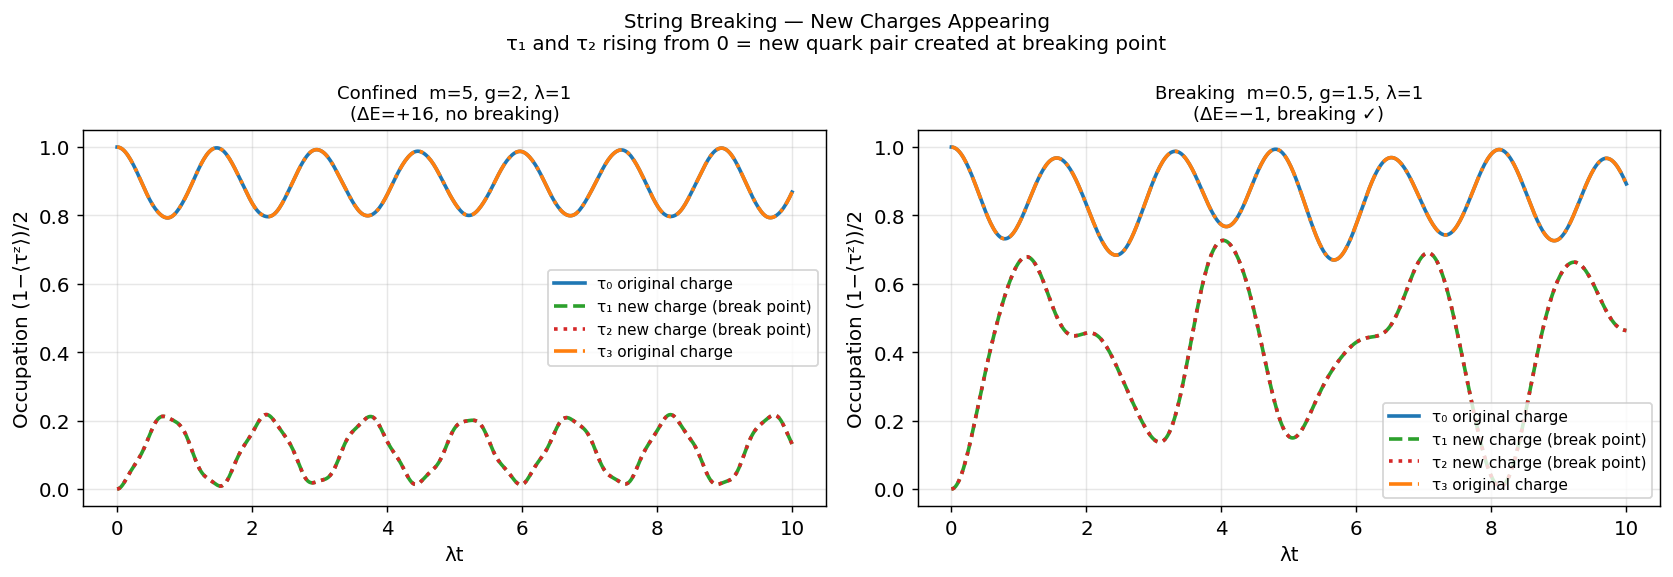

In [22]:
# ── Plot B: Occupation at each matter site ───────────────────────────────────
# This shows WHERE the charges are at each moment in time.
# The key observable: τ₁ and τ₂ rising from 0 = new charges appearing
# at the breaking point = new quark pair created from the vacuum.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (label, (m, g, lam)) in zip(axes, breaking_params.items()):

    # Run exact time evolution
    states = evolve(build_H7(m, g, lam), psi0, times)

    # τ₀: original left charge — starts at 1, decreases if charge moves inward
    ax.plot(times, [occ(s, TZ0) for s in states],
            'C0', lw=2,      label='τ₀ original charge')

    # τ₁: left middle site starts at 0, rises if new charge appears here
    # This is the LEFT side of the breaking point
    ax.plot(times, [occ(s, TZ1) for s in states],
            'C2', lw=2, ls='--', label='τ₁ new charge (break point)')

    # τ₂: right middle site starts at 0, rises if new charge appears here
    # This is the RIGHT side of the breaking point
    # By symmetry τ₂ always mirrors τ₁ exactly
    ax.plot(times, [occ(s, TZ2) for s in states],
            'C3', lw=2, ls=':',  label='τ₂ new charge (break point)')

    # τ₃: original right charge starts at 1, mirrors τ₀ by symmetry
    ax.plot(times, [occ(s, TZ3) for s in states],
            'C1', lw=2, ls='-.', label='τ₃ original charge')

    ax.set_xlabel('λt')
    ax.set_ylabel('Occupation (1−⟨τᶻ⟩)/2')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8.5)
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

fig.suptitle('String Breaking — New Charges Appearing\n'
             'τ₁ and τ₂ rising from 0 = new quark pair created at breaking point',
             fontsize=11)
plt.tight_layout()
plt.show()

## Observations

**Confined case (left plot):**
τ₀ and τ₃ oscillate between 0.8 and 1.0 small yo-yo motion of the original charges. τ₁ and τ₂ oscillate between 0 and 0.20 this small occupation does not come from new charges created from the vacuum. It comes from the original charges tunneling slightly inward during the yo-yo motion. The middle sites gain small occupation because an original charge moved there temporarily not because a new one appeared.

**Breaking case (right plot):**
τ₀ and τ₃ oscillate between 0.7 and 1.0 the original charges remain predominantly present at the endpoints but show larger
amplitude oscillations than in the confined case. τ₁ and τ₂ rise from 0 up to 0.75 at their peaks genuinely new charges
are appearing at the middle sites. This large occupation comes from the two-meson state |1110111⟩ where all four matter sites
carry charges simultaneously, which is only possible if two new charges materialized from the vacuum at the breaking point.
The two pairs of curves move in opposite directions when the new charges peak, the original charges are at their minimum.

### The quantitative signature of pair creation

The key distinction is not whether τ₁ and τ₂ gain occupation they do in both cases but how much and from what source:

| Site | Confined (max occ) | Source |
|------|-------------------|--------|
| τ₁, τ₂ | 0.20 | original charges tunneling inward |

| Site | Breaking (max occ) | Source |
|------|-------------------|--------|
| τ₁, τ₂ | 0.75 | new charges created from vacuum |

The factor of ~4 difference between 0.20 and 0.75 is the direct quantitative signature that distinguishes simple
inward tunneling from genuine pair creation.

### Connection to real QCD

In real particle physics this is exactly what happens when a quark-gluon string produced in an LHC collision has enough
energy: a new quark-antiquark pair materializes from the vacuum at the point where the string has the highest energy density.
The original quarks become the outer endpoints of two new shorter strings two mesons each of which may break again
if it still carries enough energy, producing a cascade of hadrons. Our 7-qubit simulation captures the first step of
this cascade in a fully quantum mechanical framework.

#### Plot C: Flux on Each Link: Watching the String Snap

The previous two plots showed string breaking from the matter perspective where the charges are. This plot shows the same
process from the **gauge field perspective** where the flux is.

### The gauge field observable

For each link we measure the expectation value of σᶻ:

$$\langle\sigma^z_{(n,v)}\rangle$$

This directly tells us the flux state of each link:

- **⟨σᶻ⟩ = −1**: the link carries flux → it is part of a string
- **⟨σᶻ⟩ = +1**: the link carries no flux → it is broken or empty

### The initial state flux

At t=0 all three links carry full flux:  

σ₀: ⟨σᶻ⟩ = −1 (flux present : part of left section of string)
σ₁: ⟨σᶻ⟩ = −1 (flux present : the middle link that will snap)
σ₂: ⟨σᶻ⟩ = −1 (flux present : part of right section of string)  

### What to look for

**If the string stays intact:**
All three links should remain near −1 throughout flux stays on every link, string is continuous.

**If the string breaks:**
σ₁ (middle link) should rise toward +1 the middle link loses its flux when the string snaps. σ₀ and σ₂ (outer links)
should stay predominantly negative they become the links of the two new separate mesons and keep their flux.

The middle link σ₁ is therefore the direct indicator of string breaking it is the precise location where the gluon flux tube dissolves.

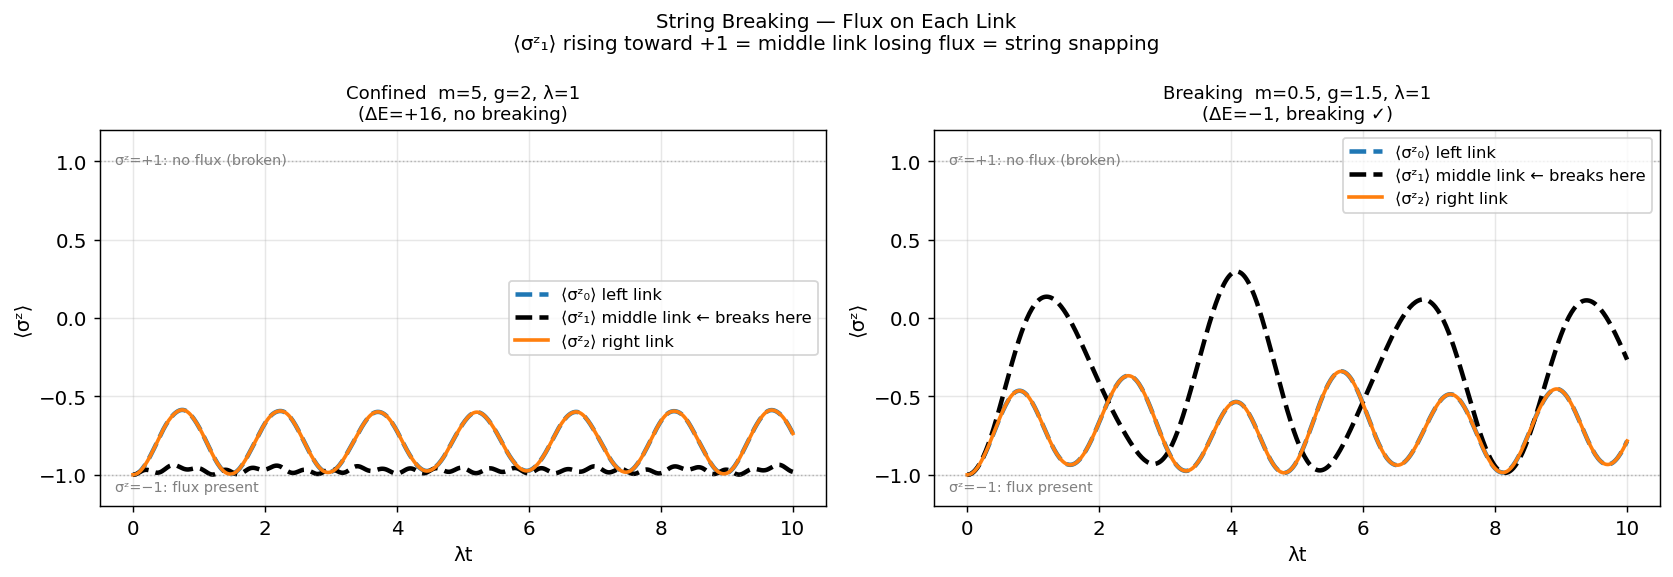

In [34]:
# ── Plot C: Flux on each link ────────────────────────────────────────────────
# This shows the gauge field perspective of string breaking.
# We measure ⟨σᶻ⟩ on each link directly.
# σᶻ eigenvalue: −1 for |1⟩ (flux present), +1 for |0⟩ (no flux)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (label, (m, g, lam)) in zip(axes, breaking_params.items()):

    # Run exact time evolution
    states = evolve(build_H7(m, g, lam), psi0, times)

    # Left link σ₀: should stay near −1 in both cases
    # In the breaking case it becomes the link of the left meson (τ₀-τ₁)
    ax.plot(times,
        [float(np.real(s.conj() @ SZ0 @ s)) for s in states],
        'C0', lw=2.5, ls='--', label='⟨σᶻ₀⟩ left link')


    # Middle link σ₁: THE KEY OBSERVABLE
    # Confined: stays near −1 (flux always present, string intact)
    # Breaking: rises toward +1 (flux dissolves, string snaps here)
    ax.plot(times,
            [float(np.real(s.conj() @ SZ1 @ s)) for s in states],
            'k', lw=2.5, ls='--', label='⟨σᶻ₁⟩ middle link ← breaks here')

    # Right link σ₂: mirrors σ₀ by symmetry of the initial state
    # In the breaking case it becomes the link of the right meson (τ₂-τ₃)
    ax.plot(times,
        [float(np.real(s.conj() @ SZ2 @ s)) for s in states],
        'C1', lw=2, ls='-', label='⟨σᶻ₂⟩ right link')

    # Reference lines marking the two extreme values
    ax.axhline(-1, color='gray', lw=0.8, ls=':', alpha=0.5)  # full flux
    ax.axhline(+1, color='gray', lw=0.8, ls=':', alpha=0.5)  # no flux

    # Labels explaining what each horizontal line means physically
    ax.text(0.02, 0.04, 'σᶻ=−1: flux present',
            transform=ax.transAxes, fontsize=8, color='gray')
    ax.text(0.02, 0.91, 'σᶻ=+1: no flux (broken)',
            transform=ax.transAxes, fontsize=8, color='gray')

    ax.set_xlabel('λt')
    ax.set_ylabel('⟨σᶻ⟩')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(-1.2, 1.2)

fig.suptitle('String Breaking — Flux on Each Link\n'
             '⟨σᶻ₁⟩ rising toward +1 = middle link losing flux = string snapping',
             fontsize=11)
plt.tight_layout()
plt.show()

### Observations

**Confined case (left plot):**
All three links oscillate with small amplitude close to −1. σ₀, σ₁, and σ₂ all stay between −1 and −0.6 throughout.
The flux is present on all three links at all times the string remains intact. The small oscillations reflect the
yo-yo motion slightly compressing and stretching the string but never breaking it.

**Breaking case (right plot):**
σ₀ and σ₂ (outer links) oscillate between −1 and −0.4 they lose some flux but remain predominantly negative.
These become the links of the two new mesons after breaking and retain most of their flux.

σ₁ (middle link) behaves completely differently from the outer links it swings dramatically between −1 and approximately
+0.3. This is a much larger amplitude than the outer links and in the opposite direction. When σ₁ reaches its positive
peaks it has lost most of its flux ⟨σᶻ₁⟩ = +0.3 means the middle link is predominantly empty of flux at those
moments. This is the direct gauge field signature of string breaking: the middle link is repeatedly losing and regaining
its flux as the system quantum mechanically oscillates between the long string and the two-meson configurations.


#### The three plots together tell a complete story

Each plot is a different perspective on the same physical event:

| Plot | Perspective | Key signal |
|------|-------------|-----------|
| Plot A (population) | Which configuration | Two-meson population grows |
| Plot B (occupation) | Where charges are | τ₁ and τ₂ rise from 0 |
| Plot C (flux) | Where flux is | σ₁ rises toward +1 |

All three signals are fully consistent with each other and with the physical picture of string breaking. Together they constitute
a complete quantum mechanical description of the string breaking process from both the matter and gauge field perspectives.

### Why σ₁ never fully reaches +1

The middle link reaches approximately +0.3 but not the full +1 value. This is because the two-meson state |1110111⟩ is
only one of eight physical states. The system quantum mechanically oscillates between all available configurations simultaneously
it never fully collapses into the two-meson state. Full +1 would require the system to be purely in the two-meson state at that
instant, which does not happen because of quantum superposition.
This quantum oscillation between broken and unbroken string is precisely the non-classical behavior that makes this simulation
physically interesting.